In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("imdb_data.csv")
df.head()

,id,primaryTitle,originalTitle,isAdult,runtimeMinutes,genres,averageRating,numVotes,budget,gross,release_date,directors
0,tt0035423,Kate & Leopold,Kate & Leopold,0,118,"Comedy,Fantasy,Romance",6.4,87925,48000000,76019048.0,"December 11, 2001",James Mangold
1,tt0065421,The Aristocats,The AristoCats,0,78,"Adventure,Animation,Comedy",7.1,111758,4000000,35459543.0,"December 11, 1970",Wolfgang Reitherman
2,tt0065938,Kelly's Heroes,Kelly's Heroes,0,144,"Adventure,Comedy,War",7.6,52628,4000000,5200000.0,"January 1, 1970",Brian G. Hutton
3,tt0066026,M*A*S*H,M*A*S*H,0,116,"Comedy,Drama,War",7.4,75784,3500000,81600000.0,"January 25, 1970",Robert Altman
4,tt0066206,Patton,Patton,0,172,"Biography,Drama,War",7.9,106476,12000000,61749765.0,"February 4, 1970",Franklin J. Schaffner


In [30]:
df.tail()

,id,primaryTitle,originalTitle,isAdult,runtimeMinutes,genres,averageRating,numVotes,budget,gross,release_date,directors
3343,tt9770150,Nomadland,Nomadland,0,107,Drama,7.3,175977,5000000,39458207.0,2020-09-11,Chloé Zhao
3344,tt9777666,The Tomorrow War,The Tomorrow War,0,138,"Action,Adventure,Drama",6.6,220617,200000000,14400000.0,2021-06-30,Chris McKay
3345,tt9784798,Judas and the Black Messiah,Judas and the Black Messiah,0,126,"Biography,Drama,History",7.4,88568,26000000,7478009.0,2021-02-01,Shaka King
3346,tt9844522,Escape Room: Tournament of Champions,Escape Room: Tournament of Champions,0,88,"Action,Adventure,Horror",5.7,56955,15000000,65774490.0,2021-07-01,Adam Robitel
3347,tt9893250,I Care a Lot,I Care a Lot,0,118,"Comedy,Crime,Drama",6.4,141433,14000000,1351662.0,2020-09-12,J Blakeson


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3348 non-null   str    
 1   primaryTitle    3348 non-null   str    
 2   originalTitle   3348 non-null   str    
 3   isAdult         3348 non-null   int64  
 4   runtimeMinutes  3348 non-null   int64  
 5   genres          3348 non-null   str    
 6   averageRating   3348 non-null   float64
 7   numVotes        3348 non-null   int64  
 8   budget          3348 non-null   int64  
 9   gross           3297 non-null   float64
 10  release_date    3343 non-null   str    
 11  directors       3348 non-null   str    
dtypes: float64(2), int64(4), str(6)
memory usage: 314.0 KB


In [29]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              3348 non-null   str           
 1   primaryTitle    3348 non-null   str           
 2   originalTitle   3348 non-null   str           
 3   isAdult         3348 non-null   int64         
 4   runtimeMinutes  3348 non-null   int64         
 5   genres          3348 non-null   str           
 6   averageRating   3348 non-null   float64       
 7   numVotes        3348 non-null   int64         
 8   budget          3348 non-null   int64         
 9   gross           3297 non-null   float64       
 10  release_date    3214 non-null   datetime64[us]
 11  directors       3348 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(4), str(5)
memory usage: 314.0 KB


In [27]:
df["isAdult"].value_counts(dropna=False)

isAdult
0    3348
Name: count, dtype: int64

In [23]:
df.describe()

,isAdult,runtimeMinutes,averageRating,numVotes,budget,gross
count,3348.0,3348.000000,3348.00000,3.348000e+03,3.348000e+03,3.297000e+03
mean,0.0,112.739845,6.73853,2.155492e+05,5.039280e+07,1.681599e+08
std,0.0,19.927703,0.88221,2.480211e+05,5.178614e+07,2.366507e+08
min,0.0,63.000000,1.00000,5.000400e+04,1.800000e+01,2.100000e+02
25%,0.0,98.000000,6.20000,7.897700e+04,1.500000e+07,3.623022e+07
50%,0.0,109.000000,6.80000,1.290400e+05,3.200000e+07,8.821516e+07
75%,0.0,124.000000,7.30000,2.468495e+05,6.800000e+07,2.008117e+08
max,0.0,242.000000,9.30000,2.817283e+06,3.560000e+08,2.923706e+09


In [24]:
print("The amount of not null values in column primaryTitle is:", len(df["primaryTitle"].dropna()))

The amount of not null values in column primaryTitle is: 3348


In [25]:
print("The amount of unique movie ids is:")
print(len(df.drop_duplicates(subset="id")))

The amount of unique movie ids is:
3348


# Data Cleaning & Preparation

In [34]:
df = df[(df["budget"] > 0) & (df["gross"] > 0)]

# Extract year and decade (needed for time analysis)
df["year"] = df["release_date"].dt.year
df["decade"] = (df["year"] // 10) * 10

# Calculate profitability (gross - budget)
df["profit"] = df["gross"] - df["budget"]

# Drop rows with missing values where needed
df = df.dropna(subset=["gross", "budget", "release_date"])

df.head()

,id,primaryTitle,originalTitle,isAdult,runtimeMinutes,genres,averageRating,numVotes,budget,gross,release_date,directors,year,decade,profit
0,tt0035423,Kate & Leopold,Kate & Leopold,0,118,"Comedy,Fantasy,Romance",6.4,87925,48000000,76019048.0,2001-12-11,James Mangold,2001,2000,28019048.0
1,tt0065421,The Aristocats,The AristoCats,0,78,"Adventure,Animation,Comedy",7.1,111758,4000000,35459543.0,1970-12-11,Wolfgang Reitherman,1970,1970,31459543.0
2,tt0065938,Kelly's Heroes,Kelly's Heroes,0,144,"Adventure,Comedy,War",7.6,52628,4000000,5200000.0,1970-01-01,Brian G. Hutton,1970,1970,1200000.0
3,tt0066026,M*A*S*H,M*A*S*H,0,116,"Comedy,Drama,War",7.4,75784,3500000,81600000.0,1970-01-25,Robert Altman,1970,1970,78100000.0
4,tt0066206,Patton,Patton,0,172,"Biography,Drama,War",7.9,106476,12000000,61749765.0,1970-02-04,Franklin J. Schaffner,1970,1970,49749765.0


# least profitable and most profitable movies in the database

In [35]:
most_profitable = df.loc[df["profit"].idxmax()]
least_profitable = df.loc[df["profit"].idxmin()]

most_profitable[["primaryTitle","profit"]], least_profitable[["primaryTitle","profit"]]

(primaryTitle          Avatar
 profit          2686706026.0
 Name: 1762, dtype: object,
 primaryTitle     Red Notice
 profit         -199821857.0
 Name: 3294, dtype: object)

In [37]:
print("The most profitable movie is Avatar, the least is Red Notice")

The most profitable movie is Avatar, the least is Red Notice


# Is budget correlated with profitability? 

In [ ]:
correlation_budget_profit = df['budget'].corr(df['profit'])
correlation_budget_profit

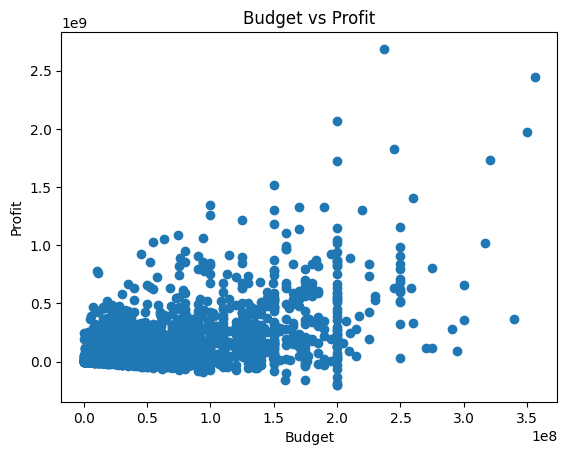

In [36]:
plt.scatter(df["budget"], df["profit"])
plt.xlabel("Budget")
plt.ylabel("Profit")
plt.title("Budget vs Profit")
plt.show()

In [39]:
print("""For the exception of a few outliers, in most cases it remains true that budget is correlated with profitability
the highest dot of profit is with a movie with higher budget, the lowest dot is on a movie with less budget""")

For the exception of a few outliers, in most cases it remains true that budget is correlated with profitability
the highest dot of profit is with a movie with higher budget, the lowest dot is on a movie with less budget


# Which is the best genre each decade? 

In [42]:
df["main_genre"] = df["genres"].str.split('|').str[0]

genre_decade = df.groupby(["decade","main_genre"])["averageRating"].mean().reset_index()

best_genre_decade = genre_decade.loc[genre_decade.groupby("decade")["averageRating"].idxmax()]
best_genre_decade

,decade,main_genre,averageRating
27,1970,"Crime,Drama",8.80
98,1980,"Animation,Drama,War",8.50
194,1990,"Action,Sci-Fi",8.65
367,2000,"Adventure,Drama,War",8.40
565,2010,"Adventure,Drama,Sci-Fi",8.35
692,2020,"Action,Drama",8.30


In [48]:
print("The table has the decade, main genres and average ratings of said rating, so for example 1970s best genres are Crime and Drama")

The table has the decade, main genres and average ratings of said rating, so for example 1970s best genres are Crime and Drama


# Is profitability correlated with rating?

In [44]:
correlation_profit_rating = df["profit"].corr(df["averageRating"])
correlation_profit_rating

np.float64(0.17196909368677277)

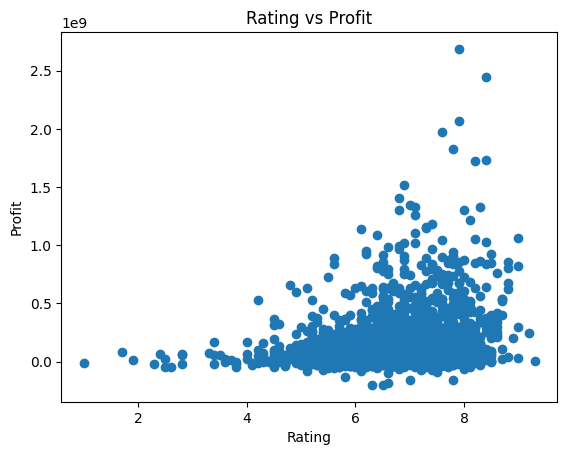

In [46]:
plt.scatter(df["averageRating"], df["profit"])
plt.xlabel("Rating")
plt.ylabel("Profit")
plt.title("Rating vs Profit")
plt.show()

In [49]:
print("""As expected, rating does have correlation with profit. With just a brief glance, one can tell that with more rating, the dots get higher on the graph
And even though there are still high rated movies with low profits, we can see an overall increase in profit as the rating increases""")

As expected, rating does have correlation with profit. With just a brief glance, one can tell that with more rating, the dots get higher on the graph
And even though there are still high rated movies with low profits, we can see an overall increase in profit as the rating increases
